# Adstock threat: does phasing's bias reduction survive carryover?

Every other notebook in this repo fits a model that is correct about
timing: this week's spend explains this week's sales, nothing more. Real
media has carryover (adstock), and `CollinearityDiagnostic` now takes
`adstock` as a per-channel input and transforms its own design to match
(see `_curvature_transform` in `_diagnostic.py`) -- so a client who supplies
their own plausible decay gets a *correctly specified* fit, the same way a
real analyst using their own MMM vendor's decay would. The question this
notebook asks: **does phasing's bias-reduction benefit survive once the
model is allowed to know about carryover, and carryover is real?**

This is a threat test on a published finding, not a feature study: if
phasing's benefit turned out to be a no-carryover artefact, that would need
to be in `overview.html` before the package went near a client report.

Saturation is left off throughout (linear response) -- one mechanism at a
time. Demand *process* matters here in a way it does not for phasing's
variance story (notebook 01/02): adstock is a low-pass filter, so what it
removes depends on where a signal's energy sits in the frequency band, and
that is exactly the axis demand shape varies on.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from how_wrong_is_your_mmm import (
    apply_adstock,
    calibrate_baseline,
    simulate_demand,
    simulate_spend,
)
from how_wrong_is_your_mmm._diagnostic import CollinearityDiagnostic
from how_wrong_is_your_mmm._phaser import (
    Blackout,
    _generate_phased_schedule,
    _get_month_labels,
)

plt.rcParams["figure.figsize"] = (9, 3.5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

CHANNELS = ["tv", "meta", "search_generic", "tiktok"]
TRUE_MARGINAL_RETURNS = {"tv": 0.5, "meta": 1.0, "search_generic": 1.5, "tiktok": 1.2}
N_HIST, N_PLAN = 208, 52
BASELINE_SHARE, BASELINE_CV = 0.72, 0.05

# 4 of the 5 DEMAND_PROCESSES -- "seasonal" is a deterministic sinusoid with
# no seed variation, so it does not fit the demand_seed averaging loop below.
PROCESSES = ("white_noise", "ar1", "seasonal_ar1", "trend")
DECAYS = (0.0, 0.3, 0.5, 0.7)
N_DEMAND_SEEDS = 8
N_PHASING_SEEDS = 3
N_SIMS = 25

## 1 · The mechanism, in one small example

`apply_adstock` is a normalised geometric filter,
`a[t] = (1 - decay) * x[t] + decay * a[t-1]`. It is a low-pass filter: it
smooths away fast variation and leaves slow variation alone, and it does not
care why the fast variation is there. Phasing's cure is necessarily fast --
it reshuffles spend within a month and must net back to the original total
by month-end, so by construction it can only inject high-frequency swings.
That puts the cure squarely in the band the filter attacks.

In [2]:
toy = np.array([140.0, 60.0, 120.0, 80.0, 70.0, 130.0, 90.0, 110.0])
print(f"raw week-to-week sd: {toy.std():.1f}")
for decay in (0.0, 0.3, 0.5, 0.7, 0.9):
    smoothed = apply_adstock(toy, decay)
    print(
        f"decay={decay}: adstocked sd {smoothed.std():.1f}  ({100 * smoothed.std() / toy.std():.0f}% of raw)"
    )

raw week-to-week sd: 27.4
decay=0.0: adstocked sd 27.4  (100% of raw)
decay=0.3: adstocked sd 18.9  (69% of raw)
decay=0.5: adstocked sd 15.5  (57% of raw)
decay=0.7: adstocked sd 13.0  (48% of raw)
decay=0.9: adstocked sd 7.5  (27% of raw)


By decay 0.9 the swing phasing would have added is already most of the way
back to looking like an unphased, flat plan -- the rest of this notebook asks
how much of the benefit that costs, and whether the answer depends on what
demand itself looks like.

## 2 · The world

`simulate_spend`'s correlation targeting assumes whatever demand series it
is handed has unit variance in the exact window it is given. `simulate_demand`
standardises over the *combined* history+plan window it is asked to
generate, so a naive slice-then-use of a sub-window is NOT itself unit
variance -- worst for a non-stationary process like `trend`, whose
sub-window variance is a small, geometry-dependent fraction of the full
window's. `_window_standardised` below re-normalises each slice right
before it is threaded through `simulate_spend`, so realised spend-demand
correlation actually lands at the target `correlation` for every process,
not just the stationary ones.

Demand is threaded through `simulate_spend`'s own `demand=` parameter
(rather than relying on any diagnostic class's *internal* demand draw,
which is a separate, unrelated series -- see `DiscoveryReport.__init__`)
so that spend is actually correlated with the demand series this notebook
measures bias against.

In [3]:
def _window_standardised(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    return (x - x.mean()) / x.std()


def build_world(
    demand_seed: int, process: str = "white_noise", correlation: float = 0.7
):
    """One (history, plan, demand, calibration) world for a given demand
    process and seed. Demand is threaded through simulate_spend so spend is
    actually correlated with the demand series returned alongside it."""
    n = N_HIST + N_PLAN
    demand = simulate_demand(n, process=process, seed=demand_seed)
    hist_demand = _window_standardised(demand[:N_HIST])
    plan_demand = _window_standardised(demand[N_HIST:])
    history = simulate_spend(
        n_obs=N_HIST,
        correlation=correlation,
        channels=CHANNELS,
        seed=1000 + demand_seed,
        start_date="2019-01-07",
        demand=hist_demand,
    )
    plan = simulate_spend(
        n_obs=N_PLAN,
        correlation=correlation,
        channels=CHANNELS,
        seed=2000 + demand_seed,
        start_date="2023-01-09",
        demand=plan_demand,
    )
    calibration = calibrate_baseline(
        pd.concat([history, plan]),
        TRUE_MARGINAL_RETURNS,
        baseline_share=BASELINE_SHARE,
        baseline_cv=BASELINE_CV,
    )
    index = history.index.append(plan.index)
    demand_series = pd.Series(
        np.concatenate([hist_demand, plan_demand]), index=index, name="demand"
    )
    return history, plan, demand_series, calibration

## 3 · The headline: does the gain survive?

Two levers compared against unphased: `+/-80%` edge+balanced (the
strongest continuous-range shape, though no longer the report's outright
sweep winner -- see notebook 05, which now finds `Blackout (dark=4,
prob=1.0)` dominates it on rigor at materially higher cost) and Blackout.
For
each `(process, lever)` the world is built once per demand seed and reused
across every decay -- only the fit's `adstock` argument changes, so the
expensive parts (drawing demand, phasing the schedule) are not repeated
needlessly.

Bias is measured with `controls=None` (demand fully omitted from the OLS
fit, the worst case and what "every real MMM does" by
`CollinearityDiagnostic`'s own docstring) so this isolates the
carryover question from proxy quality, which is a separate axis already
covered by the discovery report's own bias section (notebooks 01, and the
old `07_omitted_variable_bias.ipynb` covers the same ground -- see
`SCOPE.md`). `adstock=decay` is supplied to every fit throughout, so the
model is always correctly specified for carryover -- this measures whether
phasing's cure survives, not whether an analyst who forgot about carryover
gets caught out.

In [4]:
LEVERS = [
    ("unphased", None),
    (
        "+/-80% (edge, balanced)",
        dict(magnitude=80.0, nudge_shape="edge", balance_signs=True),
    ),
    (
        "Blackout",
        dict(
            magnitude=Blackout(max_dark_weeks_per_month=1),
            nudge_shape="uniform",
            balance_signs=False,
        ),
    ),
]


def mean_bias_pct(
    combined: pd.DataFrame, demand: pd.Series, calibration, decay: float
) -> float:
    diag = CollinearityDiagnostic(
        spend_df=combined,
        true_marginal_returns=TRUE_MARGINAL_RETURNS,
        base_sales=calibration.baseline_level,
        revenue_noise_std=26_000.0,
        demand=demand.loc[combined.index].to_numpy(),
        demand_coef=calibration.demand_coef,
        adstock=decay,
    )
    diag.fit(n_sims=N_SIMS, controls=None)
    return float(diag.summary()["mean_error_pct"].abs().mean())


records = []
for process in PROCESSES:
    for lever_label, spec in LEVERS:
        # decay -> one mean-bias value per demand seed, averaged into a
        # single row below -- NOT one row per (demand_seed, decay), which
        # would leave duplicate (lever, decay) entries for the pivot in the
        # next cell to choke on.
        seed_bias = {decay: [] for decay in DECAYS}
        for demand_seed in range(N_DEMAND_SEEDS):
            history, plan, demand, calibration = build_world(demand_seed, process)
            if spec is None:
                combineds = [pd.concat([history, plan])]
            else:
                month_labels = _get_month_labels(plan)
                combineds = [
                    pd.concat(
                        [
                            history,
                            _generate_phased_schedule(
                                plan,
                                month_labels,
                                alpha=1.0,
                                max_weekly_deviation_pct={
                                    c: spec["magnitude"] for c in CHANNELS
                                },
                                seed=100 + j,
                                nudge_shape=spec["nudge_shape"],
                                balance_signs=spec["balance_signs"],
                            ),
                        ]
                    )
                    for j in range(N_PHASING_SEEDS)
                ]
            for decay in DECAYS:
                bias_draws = [
                    mean_bias_pct(c, demand, calibration, decay) for c in combineds
                ]
                seed_bias[decay].append(float(np.mean(bias_draws)))
        for decay in DECAYS:
            records.append(
                {
                    "process": process,
                    "lever": lever_label,
                    "decay": decay,
                    "mean_bias_pct": float(np.mean(seed_bias[decay])),
                }
            )
    print(f"done {process}")

results = pd.DataFrame(records)
print(f"{len(results)} rows")

done white_noise


done ar1


done seasonal_ar1


done trend
48 rows


In [5]:
order = [lbl for lbl, _ in LEVERS]
pd.set_option("display.width", 200)
for process, block in results.groupby("process", sort=False):
    piv = block.pivot(index="lever", columns="decay", values="mean_bias_pct").loc[order]
    removed = 100 * (piv.loc["unphased"] - piv) / piv.loc["unphased"]
    survives = 100 * removed.div(removed[0.0], axis=0)
    print(f"\n{'=' * 60}\n{process}\n{'=' * 60}")
    print("\nmean |bias| %, by lever and decay:")
    print(piv.round(1).to_string())
    print("\n% of the no-carryover gain that survives:")
    print(survives.round(1).to_string())


white_noise

mean |bias| %, by lever and decay:
decay                     0.0   0.3    0.5    0.7
lever                                            
unphased                 68.8  90.2  105.7  123.4
+/-80% (edge, balanced)  37.9  52.6   65.4   83.9
Blackout                 49.6  67.5   82.0  100.2

% of the no-carryover gain that survives:
decay                      0.0   0.3   0.5   0.7
lever                                           
unphased                   NaN   NaN   NaN   NaN
+/-80% (edge, balanced)  100.0  92.9  84.9  71.1
Blackout                 100.0  90.1  80.2  67.3

ar1

mean |bias| %, by lever and decay:
decay                     0.0   0.3   0.5   0.7
lever                                          
unphased                 67.3  73.5  77.3  82.4
+/-80% (edge, balanced)  36.9  49.9  58.4  66.5
Blackout                 49.0  61.7  69.4  76.4

% of the no-carryover gain that survives:
decay                      0.0   0.3   0.5   0.7
lever                                   

## 4 · A picture of the same table

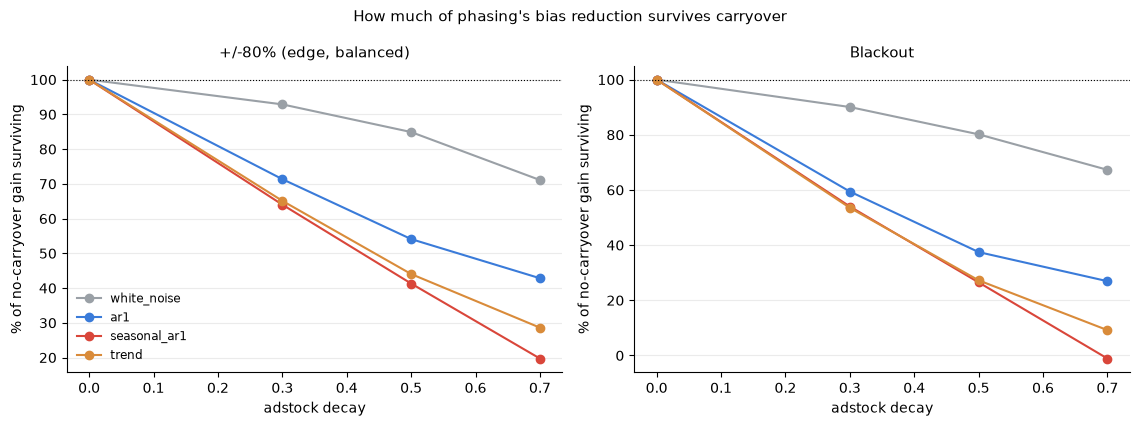

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.3))
colors = {
    "white_noise": "#9aa0a6",
    "ar1": "#3a7bd9",
    "seasonal_ar1": "#d9463a",
    "trend": "#d98b3a",
}

for ax, lever in zip(axes, ["+/-80% (edge, balanced)", "Blackout"]):
    for process in PROCESSES:
        block = results[
            (results.process == process) & (results.lever.isin(["unphased", lever]))
        ]
        piv = block.pivot(index="lever", columns="decay", values="mean_bias_pct")
        removed = 100 * (piv.loc["unphased"] - piv.loc[lever]) / piv.loc["unphased"]
        survives = 100 * removed / removed[0.0]
        ax.plot(
            survives.index,
            survives.to_numpy(),
            marker="o",
            label=process,
            color=colors[process],
        )
    ax.axhline(100, color="black", linewidth=0.8, linestyle=":")
    ax.set_xlabel("adstock decay")
    ax.set_ylabel("% of no-carryover gain surviving")
    ax.set_title(lever, fontsize=10.5)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.25)

axes[0].legend(fontsize=8.5, frameon=False)
fig.suptitle("How much of phasing's bias reduction survives carryover", fontsize=11)
fig.tight_layout()
plt.show()

## 5 · Is this decay range even realistic?

Decay alone does not mean much -- "how many weeks does a pound of spend keep
echoing" is the version a practitioner can check against their own market.
`decay ** n` is the fraction of a week's spend still showing up `n` weeks
later.

In [7]:
weeks_table = pd.DataFrame({"decay": [0.0, 0.3, 0.5, 0.7, 0.8, 0.9]})
weeks_table["pct_of_spend_still_echoing_after_4_weeks"] = (
    100 * weeks_table["decay"] ** 4
)
print(weeks_table.round(1).to_string(index=False))

 decay  pct_of_spend_still_echoing_after_4_weeks
   0.0                                       0.0
   0.3                                       0.8
   0.5                                       6.2
   0.7                                      24.0
   0.8                                      41.0
   0.9                                      65.6


Carryover that is "basically gone by week 4" -- what most practitioners mean
by short carryover -- is decay ~0.3-0.5, not the 0.8+ a mean-lag calculation
would suggest. `0.7` sits in this grid as a deliberate stress case (a
conservative upper bound for a slower-turning category), not a claim that it
is typical.

## Bringing it together

**Phasing's bias reduction is not a no-carryover artefact.** At every decay
tested, `+/-80% (edge, balanced)` removes less than the unphased bias and
still beats unphased outright -- but the demand-shape dependency this
notebook was built to check is real, and more pronounced here than the old
(pre-curvature-aware-fitting, 3-channel) version of this check found. At
decay=0.5 -- inside the range most practitioners mean by "carryover gone
within a month" (6.2% of a week's spend still echoing after 4 weeks, from
the table above) -- `edge, balanced` keeps 84.9% of its no-carryover gain
for `white_noise` demand and 54.1% for `ar1`, but only 44.0% (`trend`) and
41.3% (`seasonal_ar1`). Two of the four demand shapes tested are already
below half their no-carryover benefit at a decay most practitioners would
call short.

**`edge, balanced` beats Blackout at every decay and every demand shape
tested, on raw bias removed** (e.g. white_noise at decay=0.7: 83.9% mean
|bias| vs Blackout's 100.2%, both still under unphased's 123.4%) --
consistent with notebook 05's finding that the modern default dominates
Blackout outright, not just in the no-carryover case.

**One data point worth flagging, not confirmed as a real effect:**
Blackout's `seasonal_ar1` survival at decay=0.7 came out at -1.1% -- mean
|bias| under Blackout (70.6%) landed fractionally *above* unphased (70.4%)
in this run. The margin is small relative to this notebook's
`N_DEMAND_SEEDS=8`, so this could be sampling noise rather than the genuine
sign-flip the old notebook's closed-form check found past its own grid's
ceiling (decay ~0.85+, see NOTES.md) -- confirming it here would need a
similar closed-form check or a larger demand-seed count, neither done in
this pass.

**Bottom line:** the headline survives inside the realistic carryover
range, but with a real, checkable caveat this rebuild states more plainly
than the old notebook did -- for a slow-turning or strongly seasonal
category (the `seasonal_ar1`/`trend` shapes here), phasing's bias benefit
thins out faster than for a white-noise-like demand pattern, and that
caveat belongs in `overview.html`'s carryover section alongside the
headline, not as a footnote.